In [13]:
# Manejo de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento (¡VITAL en no supervisado!)
from sklearn.preprocessing import StandardScaler

# Modelos de Clustering y PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Métricas y Dendrograma
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [14]:
df = pd.read_csv("datasets/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [15]:
df.shape

(16598, 11)

In [16]:
df.isnull().sum()  

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [17]:
df = df.dropna(subset=['Year'])

In [18]:
df = df.dropna(subset=['Publisher'])

In [19]:
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  str    
 2   Platform      16291 non-null  str    
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  str    
 5   Publisher     16291 non-null  str    
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.5 MB


In [21]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [22]:
# df.drop(columns=['Rank'], inplace=True)

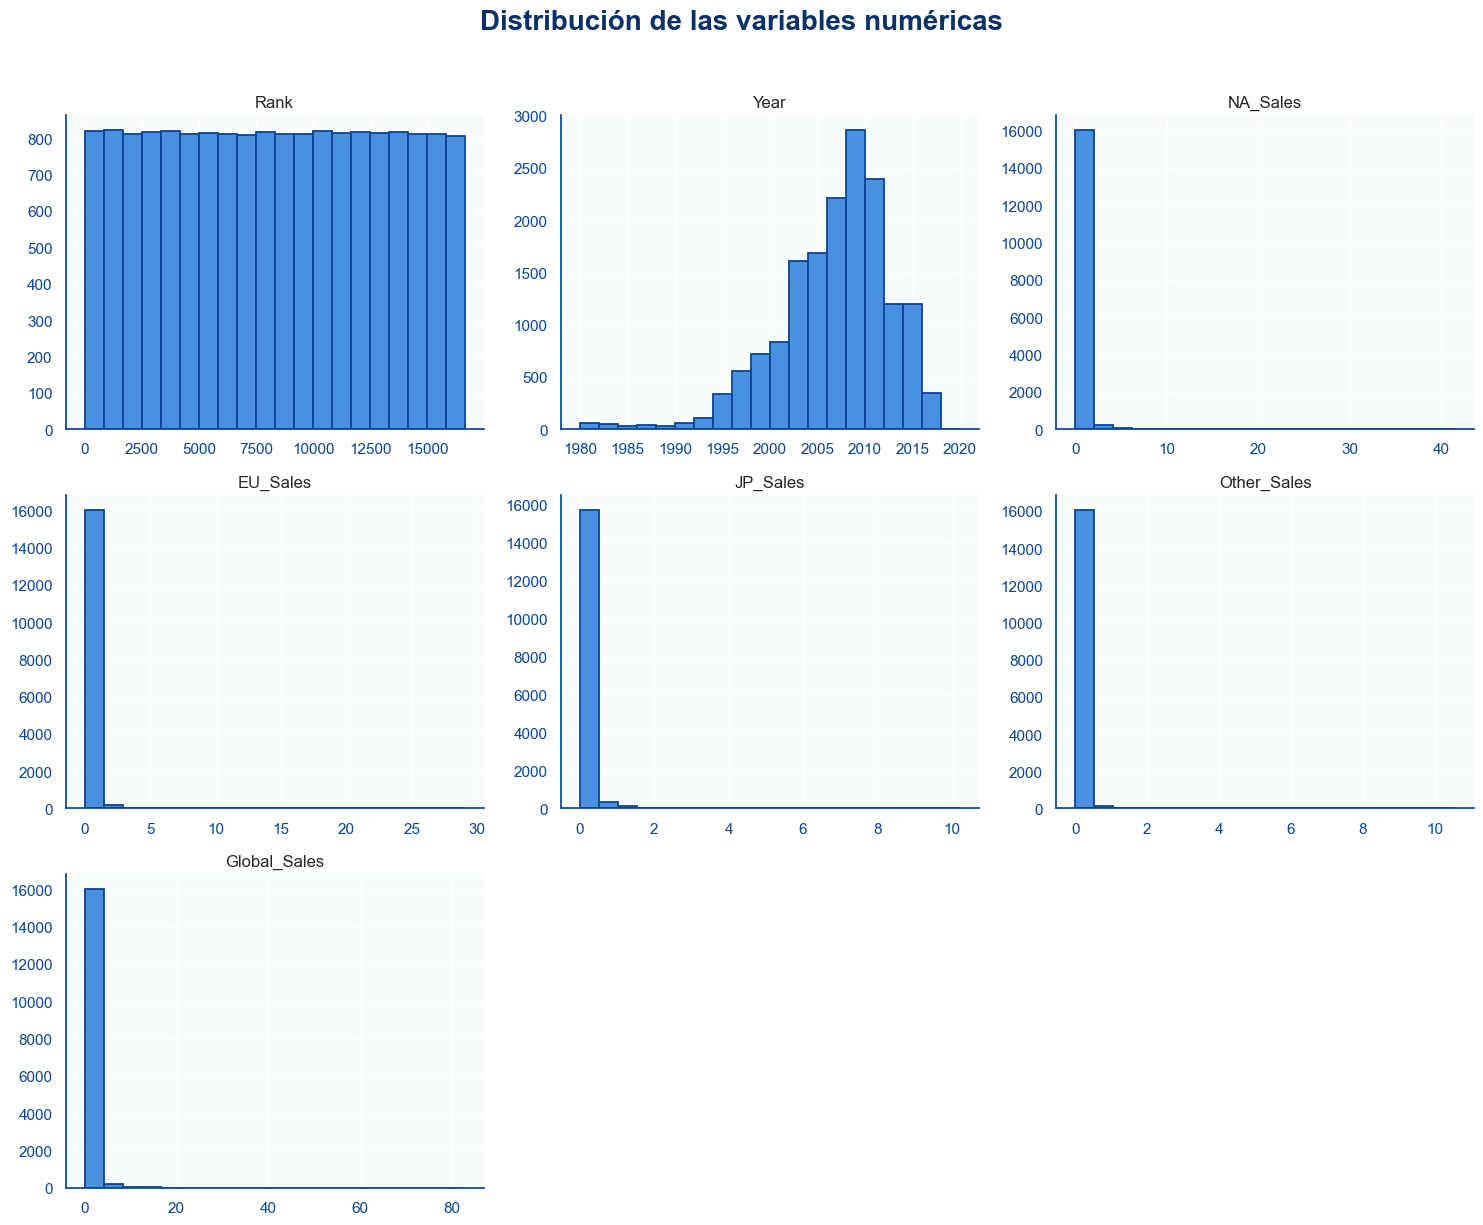

In [23]:
sns.set_theme(style="whitegrid")

color_barras = "#4a90e2"
color_borde = "#084594"

axes = df.hist(
    figsize=(15, 12),
    bins=20,
    color=color_barras,
    edgecolor=color_borde,
    linewidth=1.3
)

plt.suptitle(
    'Distribución de las variables numéricas', 
    fontsize=20, 
    fontweight='bold', 
    color='#08306b', 
    y=1.02
)

for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor('#f7fbfc')  # Fondo suave
        ax.grid(True, color='white', linewidth=1.0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#084594')
        ax.spines['bottom'].set_color('#084594')
        ax.tick_params(axis='x', colors='#084594')
        ax.tick_params(axis='y', colors='#084594')

plt.tight_layout()
plt.show()

In [24]:
df.dropna(subset=['Rank'], inplace=True)    


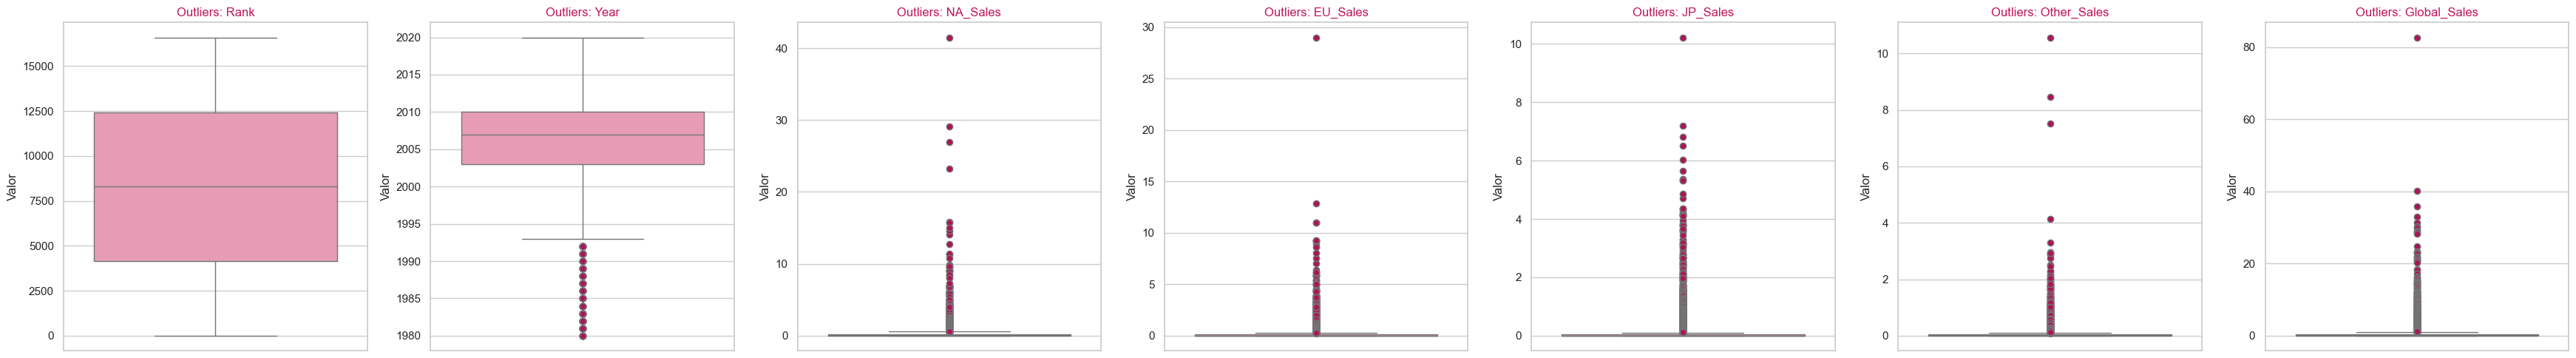

In [ ]:
vars_outliers = df.select_dtypes(include='number').columns

n = len(vars_outliers)

plt.figure(figsize=(5*n, 5))

for i, col in enumerate(vars_outliers):
    plt.subplot(1, n, i+1)
    
    sns.boxplot(
        y=df[col],
        color='#f48fb1',
        flierprops={'markerfacecolor': '#ad1457', 'marker': 'o'}
    )
    
    plt.title(f'Outliers: {col}', fontsize=12, color='#c2185b')
    plt.ylabel('Valor')

plt.tight_layout()
plt.show()

GRAFICO DE DISPERSION

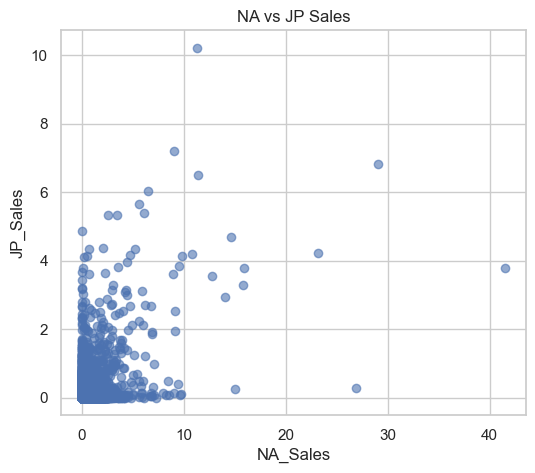

In [31]:
plt.figure(figsize=(6,5))
plt.scatter(df['NA_Sales'], df['JP_Sales'], alpha=0.6)

plt.xlabel('NA_Sales')
plt.ylabel('JP_Sales')
plt.title('NA vs JP Sales')

plt.show()

In [32]:
df.drop(columns=['Global_Sales'], inplace=True)


escalamos porque son muy distintos los valores

In [33]:
scaler = StandardScaler()
X_numeric = pd.get_dummies(df, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)


CON PCA 

In [ ]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Originalmente teníamos {X_scaled.shape[1]} columnas.")
print(f"Tras PCA, K-Means solo trabajará con {X_pca.shape[1]} columnas principales.")
print("-" * 50)